# ¿Es posible predecir el sexo de un paciente a partir de las características visuales de una sola radiografía de tórax?

Para responder esta pregunta se entrenó un modelo DenseNet-121 con resolución 128×128 y 1 época, usando Weighted BCE Loss, configurado como clasificación binaria donde la clase positiva es "femenino" (F=1) y la negativa "masculino" (M=0). El modelo se entrenó sobre todo el dataset NIH ChestX-ray14 con partición por paciente.

In [1]:
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def find_root(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / '.git').exists():
            return p
    return start
root = find_root()
os.chdir(root)

results = [('Gender', 0.989, 9944, 3066, 92, 9296, 0.855)]
df = pd.DataFrame(results, columns=['Clase', 'AUC', 'TN', 'FP', 'FN', 'TP', 'F1'])
df['Prevalencia'] = (df['TP'] + df['FN']) / (df['TN'] + df['FP'] + df['FN'] + df['TP'])
df['Muestras'] = df['TN'] + df['FP'] + df['FN'] + df['TP']
df.index += 1
df

,Clase,AUC,TN,FP,FN,TP,F1,Prevalencia,Muestras
1,Gender,0.989,9944,3066,92,9296,0.855,0.419145,22398


In [2]:
print(df.to_markdown(index=True))

|    | Clase   |   AUC |   TN |   FP |   FN |   TP |    F1 |   Prevalencia |   Muestras |
|---:|:--------|------:|-----:|-----:|-----:|-----:|------:|--------------:|-----------:|
|  1 | Gender  | 0.989 | 9944 | 3066 |   92 | 9296 | 0.855 |      0.419145 |      22398 |


La tabla muestra las métricas obtenidas. El AUC de 0.989 es excepcionalmente alto, lo que indica que el modelo logra distinguir entre radiografías de hombres y mujeres con una precisión muy cercana a la perfecta. El F1-Score de 0.855 refleja un buen balance entre precisión y sensibilidad. La prevalencia de la clase femenina es del 41.9%, lo que significa que la muestra está relativamente balanceada en cuanto a sexo, a diferencia de lo que ocurría con las enfermedades pulmonares donde el desbalance era extremo.

## Curva ROC

La curva ROC muestra la relación entre la tasa de verdaderos positivos (sensibilidad) y la tasa de falsos positivos (1 - especificidad) para distintos umbrales de clasificación. Cuanto más se acerca la curva a la esquina superior izquierda, mejor es el rendimiento del modelo. La línea diagonal punteada representa un clasificador aleatorio.

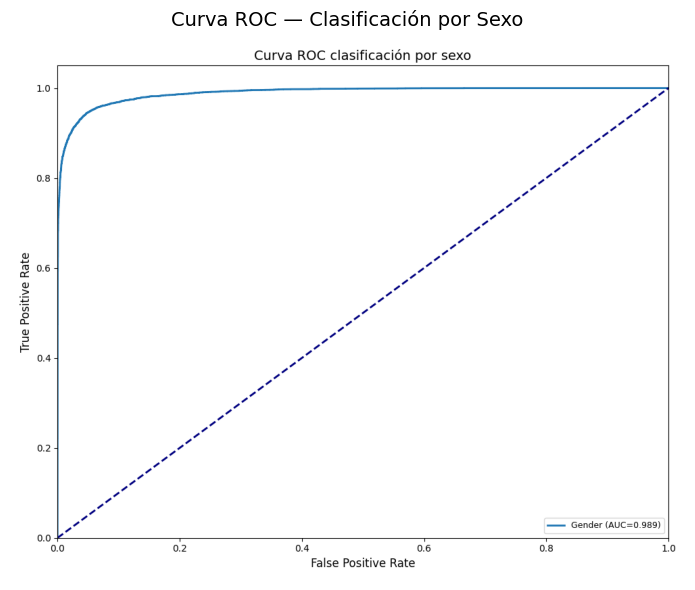

In [3]:
roc_path = root / 'results' / 'roc' / 'pregunta2_roc_all.png'
if roc_path.exists():
    img = mpimg.imread(str(roc_path))
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(img)
    ax.set_title('Curva ROC — Clasificación por Sexo', fontsize=14, pad=10)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No se encuentra pregunta2_roc_all.png')

**Figura 1.** Curva ROC del modelo de clasificación por sexo. Con un AUC de 0.989, la curva se eleva abruptamente hacia la esquina superior izquierda, muy cerca del punto ideal (0,1). Esto indica que el modelo puede separar casi perfectamente las radiografías de hombres y mujeres, muy por encima del umbral aleatorio representado por la línea diagonal.

## Matriz de Confusión

La matriz de confusión enfrenta las predicciones del modelo contra los valores reales. La diagonal principal (TN y TP) representa los aciertos. Se generó con un umbral de decisión de 0.5.

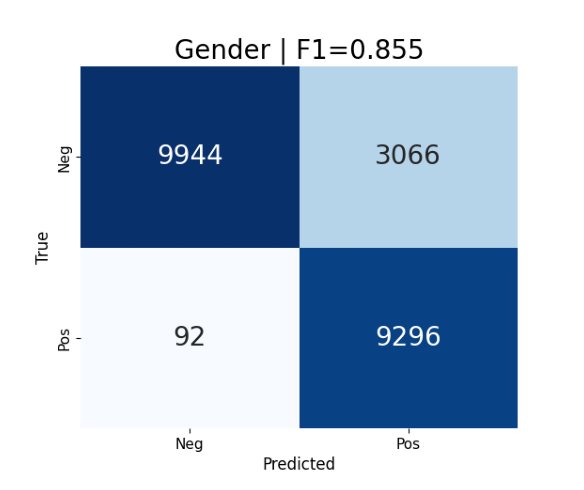

In [4]:
cm_path = root / 'results' / 'confusion' / 'full_data_gender_gender_low_res_densenet_binary_1epoch.png'
if cm_path.exists():
    img = mpimg.imread(str(cm_path))
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(img)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No se encuentra la matriz de confusión')

**Figura 2.** Matriz de confusión para la clasificación por sexo (F=1, M=0). El modelo clasificó correctamente 9944 hombres (TN) y 9296 mujeres (TP). Los errores fueron 3066 falsos positivos (hombres clasificados como mujeres) y solo 92 falsos negativos (mujeres clasificadas como hombres). Esto indica que el modelo tiene una sensibilidad muy alta para detectar mujeres (Recall=0.990), aunque con una precisión moderada (Precision=0.752) debido a los falsos positivos.

## Mapas de Activación (CAM)

Los mapas CAM (Class Activation Mapping) permiten visualizar qué regiones de una imagen fueron determinantes para la decisión de una red convolucional. Se genera un mapa de calor que se superpone a la radiografía original, donde los colores cálidos (rojo/amarillo) indican mayor contribución a la predicción. La activación para la clase $c$ en la posición espacial $(x,y)$ se calcula como:

$$M_c(x,y) = \sum_{k} w_k^c \cdot f_k(x,y)$$

donde $f_k(x,y)$ es la activación del $k$-ésimo mapa de características en la última capa convolucional y $w_k^c$ es el peso que conecta dicho mapa con la clase $c$ en el clasificador. A continuación se muestran dos ejemplos de Verdaderos Positivos (mujeres correctamente clasificadas).

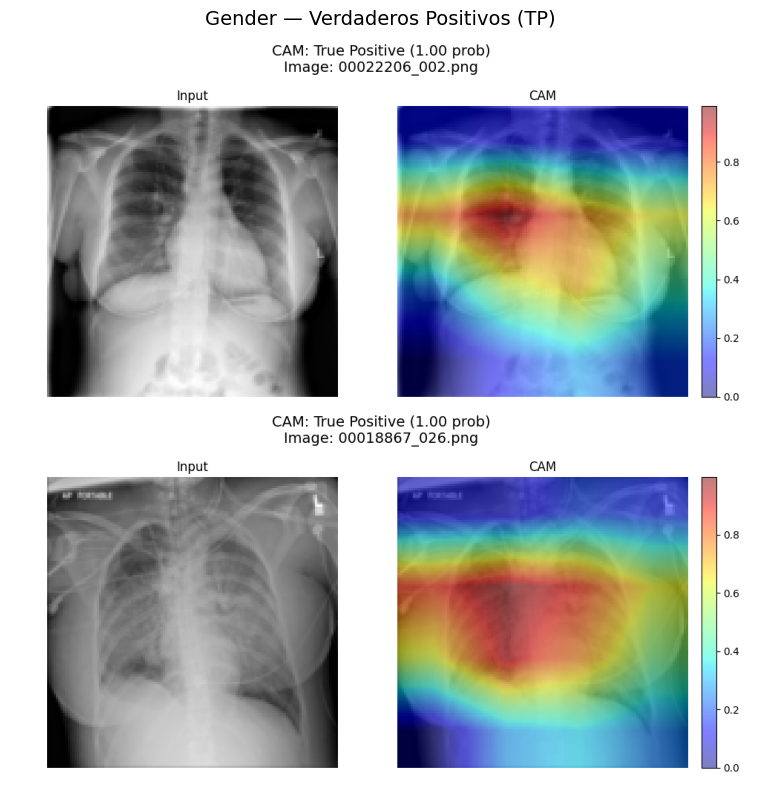

In [5]:
cam_path = root / 'results' / 'cam' / 'gender_tp_combined.png'
if cam_path.exists():
    img = mpimg.imread(str(cam_path))
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img)
    ax.set_title('Gender — Verdaderos Positivos (TP)', fontsize=14, pad=10)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No se encuentra gender_tp_combined.png')

**Figura 3.** Dos ejemplos de mujeres correctamente clasificadas. Cada fila muestra la radiografía original (izquierda) y el mapa CAM superpuesto (derecha). Las zonas en rojo y amarillo indican las regiones que más contribuyeron a la decisión del modelo. Resulta llamativo que un AUC de 0.989 se haya alcanzado con solo 1 época de entrenamiento y resolución 128×128, lo que sugiere que existen diferencias morfológicas sutiles pero consistentes entre las radiografías de tórax de hombres y mujeres que la red es capaz de capturar.

## Conclusión

Sí, es posible predecir el sexo de un paciente a partir de una radiografía de tórax con un altísimo nivel de precisión. El modelo alcanzó un AUC de 0.989 y un F1-Score de 0.855, valores que superan ampliamente a cualquier modelo de detección de enfermedades entrenado en las mismas condiciones. Esto sugiere que existen diferencias morfológicas sistemáticas entre los tórax masculino y femenino —como el tamaño y forma de la caja torácica, la densidad ósea o la proporción de tejido blando— que son fácilmente aprendidas por una red convolucional profunda. A diferencia de lo que ocurre con las enfermedades pulmonares, donde el desbalance de clases y la sutileza de los patrones radiológicos dificultan el aprendizaje, la clasificación por sexo se beneficia de tener clases relativamente balanceadas y rasgos distintivos consistentes a lo largo de todo el dataset.